## 1. 환경 세팅 및 라이브러리 로드
EDA 시각화를 위한 기본 라이브러리를 불러오고 한글 깨짐을 방지

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (Windows 환경 기준)
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False

## 2. 타겟 변수 정의 (위험 지역 라벨링)
읍면동 단위 집계로 인한 편차 희석 문제를 보정하기 위해, 선관위 기준(50%) 대신 데이터 분포를 기반으로 타겟을 재정의함.
- **기준점(Threshold):** 선거일투표율 평균 + 1표준편차 (상위 약 16% 지역)

In [ ]:
# 1.데이터 로드
df = pd.read_excel('output/cleaned_vote_data.xlsx')

#2. 임계치(평균 + 1Std) 산출
mean_val = df['선거일투표율'].mean()
std_val = df['선거일투표율'].std()
threshold = mean_val + std_val

# 3. 선관위 배정량 추가  ← 여기!
df['선관위_배정량'] = df['총선거인수'] * 0.5

# 4. 타겟 변수 생성
df['위험투표소'] = (df['선거일투표율'] > threshold).astype(int)

# 현황 체크
print(f"기준선(평균+1Std): {threshold:.1f}%")
print(f"위험 구역 수: {df['위험투표소'].sum()}개 ({df['위험투표소'].mean()*100:.1f}%)")

## 3. [PPT 9] 시도별 위험 구역 분포 (지도 시각화 대체)
전국 지도를 그리는 대신, 의사결정권자가 직관적으로 물류(투표용지) 배정 리스크를 파악할 수 있도록 시도별 위험 구역 발생 건수를 막대그래프로 시각화함.

### 📌 추가 분석: 강원도 선거일 투표율이 유독 높은 이유

데이터를 보면 강원도의 선거일 투표율은 35.7%로 전국 평균(31.8%) 대비 눈에 띄게 높다. 반면 사전투표율은 22.9%로 낮은 편인데, 이는 지리적/환경적 특성과 직결된다.

- **지리적 접근성 한계:** 강원도는 산간 및 농촌 비중이 커서 투표소까지의 이동 거리가 멀다.
- **투표 행동 패턴:** 굳이 두 번 걸음해야 하는 사전투표보다는, 지정된 선거일 당일에 동네 단위로 한 번에 이동해 투표하는 전통적인 방식을 선호함.

**💡 시사점**
"사전투표율이 오르면 선거일 투표율은 떨어진다"는 선관위의 단순한 가설은 강원도처럼 지역 특수성이 강한 곳에서는 전혀 먹히지 않는다. 투표소마다 유권자 성향과 환경이 다름에도, 이를 무시하고 전국에 일괄 50% 제한을 걸어버린 것이 이번 용지 부족 사태의 핵심 원인임을 보여준다.

In [ ]:
# 시도별 위험 구역 수 집계
danger_by_sido = df.groupby('시도')['위험투표소'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(14, 6))

# 막대그래프 렌더링
ax = sns.barplot(data=danger_by_sido, x='시도', y='위험투표소', palette='Reds_r')

# 수치 라벨 추가
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(p.get_x() + p.get_width()/2., height + 2, int(height), 
                ha='center', fontsize=11, color='black')

# 타이틀 직관적으로 수정
plt.title('시도별 잠재적 위험 구역 발생 건수 (투표용지 부족 리스크)', fontsize=15, fontweight='bold')
plt.xlabel('시·도')
plt.ylabel('위험 구역 수 (개)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 비율 그래프
danger_ratio = df.groupby('시도')['위험투표소'].mean().sort_values(ascending=False).reset_index()
danger_ratio['위험투표소'] = danger_ratio['위험투표소'] * 100

plt.figure(figsize=(14, 6))
ax = sns.barplot(data=danger_ratio, x='시도', y='위험투표소', palette='Reds_r')

for p in ax.patches:
    height = p.get_height()
    
    if height > 0:
        ax.text(p.get_x() + p.get_width()/2., height + 0.5, f'{height:.1f}%',
                ha='center', fontsize=11, color='black')

plt.title('시도별 위험 읍면동 비율 (%)', fontsize=15, fontweight='bold')
plt.xlabel('시·도')
plt.ylabel('위험 읍면동 비율 (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

gangwon = df[df['시도'] == '강원도']
print(f"강원도 읍면동 수: {len(gangwon)}개")
print(f"강원도 평균 선거일투표율: {gangwon['선거일투표율'].mean():.1f}%")
print(f"강원도 평균 사전투표율: {gangwon['사전투표율'].mean():.1f}%")
print(f"전국 평균 선거일투표율: {df['선거일투표율'].mean():.1f}%")



## 4. 규모별 위험도 체크 (U자 패턴)
총선거인수 기준으로 소/중/대 쪼개서 봤는데 그래프가 U자로 튐. 양극단이 문제.

- **소규모 (19.9%):** 모수가 적어서 몇 명만 당일에 몰려도 비율이 미친 듯이 튐 (강원도 등 농어촌 특성)
- **대규모 (17.1%):** 인구 밀집 구역이라 특정 아파트 앞 투표소 등으로 단기 쏠림 빡세게 옴 (가락1동 케이스)

**결론:** 어중간한 '중규모' 빼고는 일괄 50% 룰은 양극단에서 무조건 터짐. 지역 규모별로 다르게 줘야 함.

In [ ]:
# 선거인수 3등분 컷
df['규모_그룹'] = pd.qcut(df['총선거인수'], q=3, labels=['소규모', '중규모', '대규모'])

# 그룹별 위험 발생 비율 산출
risk_rate = df.groupby('규모_그룹')['위험투표소'].mean() * 100
risk_rate = risk_rate.reset_index()

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=risk_rate, x='규모_그룹', y='위험투표소', palette='viridis')

# 바 위에 퍼센트 달기
for p in ax.patches:
    h = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., h + 0.5, f'{h:.1f}%', 
            ha='center', fontsize=12, fontweight='bold')

plt.title('투표소 규모별 위험 발생률 (U자 패턴 확인)')
plt.xlabel('투표소 규모 (3분위)')
plt.ylabel('위험 발생률 (%)')
plt.ylim(0, risk_rate['위험투표소'].max() + 5)
plt.tight_layout()
plt.show()

## 5. [PPT 11] 사전투표율 vs 선거일투표율 (선관위 가설 검증)

선관위의 핵심 논리는 "사전투표율이 높을수록 선거일 투표자는 줄어든다"는 것이었다.
이를 산점도로 직접 검증한다.

**분석 결과**
- 사전투표율과 선거일투표율 사이에 뚜렷한 반비례 관계가 나타나지 않는다.
- 사전투표율이 높은 지역임에도 위험 기준선(37.4%)을 초과하는 읍면동이 다수 존재한다.

**핵심 결론**
사전투표율 단일 변수만으로 선거일 투표 수요를 예측하는 것은 한계가 있다.
위험 구역(빨간 점)들은 사전투표율과 무관하게 전 구간에 걸쳐 분포하며,
이는 선관위의 단순 가설이 현실을 반영하지 못했음을 보여준다.

In [ ]:
plt.figure(figsize=(9, 7))

# 범례 색상 꼬임을 막기 위해 0과 1을 아예 글자로 변환한 임시 데이터프레임 사용
plot_df = df.copy()
plot_df['리스크_라벨'] = plot_df['위험투표소'].map({0: '정상', 1: '위험'})

# 산점도 그리기
sns.scatterplot(data=plot_df, x='사전투표율', y='선거일투표율', 
                hue='리스크_라벨', 
                palette={'정상': 'lightgray', '위험': 'firebrick'}, 
                alpha=0.8, edgecolor=None)

# 통계적 위험 기준선
plt.axhline(y=threshold, color='orange', linestyle='--', linewidth=2, label=f'위험 기준선 ({threshold:.1f}%)')

plt.title('사전투표율 vs 선거일투표율 (단일 변수 예측의 한계)')
plt.xlabel('사전투표율 (%)')
plt.ylabel('선거일 투표율 (%)')

# 범례 위치 및 제목 정리
plt.legend(title='리스크 여부')
plt.tight_layout()
plt.show()

## 6. [PPT 12] 선거일 투표율 분포 (평균의 함정)

전국 평균 선거일투표율은 31.8%로, 선관위의 50% 배정량이 
충분해 보일 수 있다. 그러나 분포를 들여다보면 다른 현실이 보인다.

**분포 형태**
대부분 정규분포에 가깝지만 50% 근처까지 올라가는 극단값들이 존재한다.

**핵심 시사점**
평균(31.8%)은 안전지대에 있지만, 우측에 위치한
읍면동들은 50% 한계선에 근접하거나 초과한다.
평균만을 기준으로 정책을 설계하면 이 극단값 지역에서
반드시 용지 부족이 발생할 수밖에 없다.

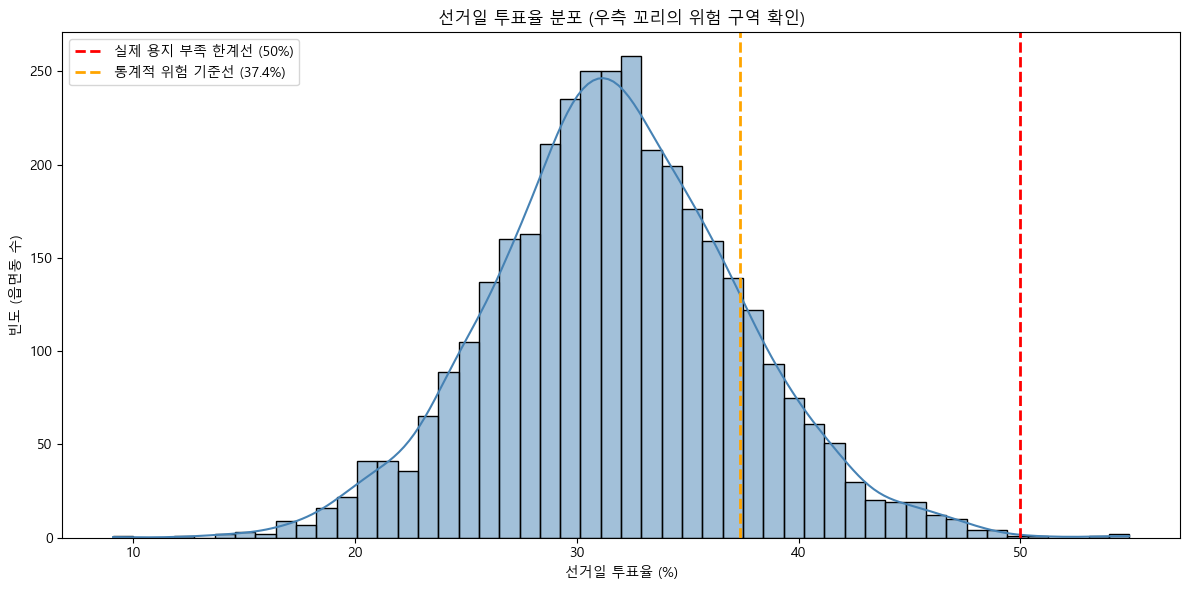

왜도: 0.11


In [26]:
plt.figure(figsize=(12, 6))

# 투표율 분포 히스토그램 그리기
sns.histplot(df['선거일투표율'], bins=50, kde=True, color='steelblue')

# 기준선 비교 (물리적 한계 vs 통계적 위험선)
plt.axvline(x=50, color='red', linestyle='--', linewidth=2, label='실제 용지 부족 한계선 (50%)')
plt.axvline(x=threshold, color='orange', linestyle='--', linewidth=2, label=f'통계적 위험 기준선 ({threshold:.1f}%)')

plt.title('선거일 투표율 분포 (우측 꼬리의 위험 구역 확인)')
plt.xlabel('선거일 투표율 (%)')
plt.ylabel('빈도 (읍면동 수)')
plt.legend()
plt.tight_layout()
plt.show()
# 왜도 확인
print(f"왜도: {df['선거일투표율'].skew():.2f}")